In [117]:
import sys, os


In [118]:
sys.path.append(os.path.abspath(".."))

In [119]:
import yfinance as yf

In [120]:
import equitytools.data

In [121]:
from equitytools_local.data import load_price_data

In [122]:
ticker_symbol = "MSFT"

In [123]:
ticker = load_price_data(ticker_symbol)

In [124]:
print(type(ticker))

<class 'yfinance.ticker.Ticker'>


In [125]:
avg_appreciation_sp500 = 0.10

In [126]:
standard_deviation__sp500 = 0.16

## Get the beta value and current price for the ticker ##

In [127]:
print(ticker)

yfinance.Ticker object <MSFT>


In [128]:
beta = ticker.info['beta']

In [129]:
print(beta)

1.084


In [130]:
current_price = ticker.info['currentPrice']

## Function that returns the inverse normal score for a normal ith specified mean and standard deviation. ##

In [137]:
from equitytools_local.modeling import inverse_normal

In [138]:
p1Bottom = inverse_normal(0.025, avg_appreciation_sp500 * abs(beta), standard_deviation__sp500 * abs(beta))

In [139]:
p1Top = inverse_normal(0.975, avg_appreciation_sp500 * abs(beta), standard_deviation__sp500 * abs(beta))

In [140]:
print (p1Bottom, p1Top)

-0.23153615347862705 0.448336153478627


In [141]:
rangeForTickerInOneYear = [ current_price * (1 + p1Bottom ) , current_price * (1 + p1Top )  ]

In [142]:
print (rangeForTickerInOneYear)

[np.float64(308.39991088595735), np.float64(581.2462651140426)]


## Plot the Result

In [143]:
from equitytools_local.plotting import plot_confidence_interval

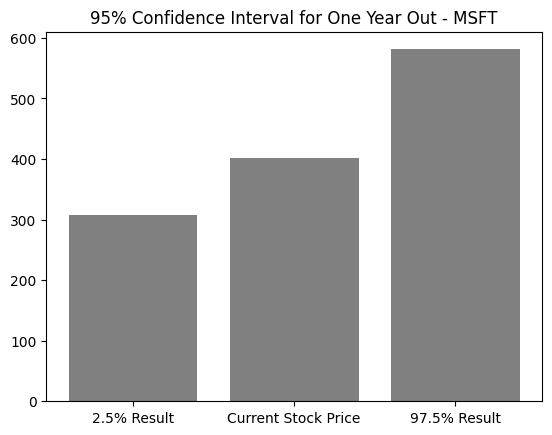

In [144]:
plot_confidence_interval(ticker_symbol, rangeForTickerInOneYear, current_price)